In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
df_train = pd.read_csv('ram.csv')
df_test = pd.read_csv('testram.csv')

print("Training dataset shape:", df_train.shape)
print("Test dataset shape:", df_test.shape)
print("\nFirst few rows of training data:")
print(df_train.head())
print("\nFirst few rows of test data:")
print(df_test.head())
print("\nTraining data types:")
print(df_train.dtypes)

Training dataset shape: (1620, 8)
Test dataset shape: (30, 8)

First few rows of training data:
   ArrivalRate device_write  cpus memory  cpuLoad  size  Throughput  \
0           10         10mb   0.5   256m        0     0        10.0   
1           10         10mb   0.5   256m      100     0        10.0   
2           10         10mb   0.5   256m     1000     0        10.0   
3           10         10mb   0.5   256m        0   250        10.0   
4           10         10mb   0.5   256m      100   250        10.0   

   ResponseTime  
0           3.9  
1           7.1  
2           4.1  
3           4.7  
4           4.1  

First few rows of test data:
   ArrivalRate device_write  cpus memory  cpuLoad  size  Throughput  \
0          120         15mb  1.50   768m      750   500        14.3   
1           60          7mb  0.75   384m      250   100         6.0   
2          120         15mb  1.50   768m      250   750        15.6   
3           30         15mb  0.75   384m       50   500

In [3]:
# Data preprocessing with numerical extraction
input_features = ['ArrivalRate', 'device_write', 'cpus', 'memory', 'size', 'cpuLoad']
output_targets = ['Throughput', 'ResponseTime']

# Helper function for memory conversion
def convert_memory(mem_str):
    if 'g' in mem_str.lower():
        return float(mem_str.lower().replace('g', '')) * 1024  # Convert GB to MB
    elif 'm' in mem_str.lower():
        return float(mem_str.lower().replace('m', ''))
    else:
        return float(mem_str)

# Process training data
print("="*50)
print("PROCESSING TRAINING DATA")
print("="*50)
data_train = df_train[input_features + output_targets].copy()
data_train = data_train.dropna(subset=output_targets)
print(f"Training dataset after removing NaN: {data_train.shape}")

# Extract numerical values from device_write
data_train['device_write_numeric'] = data_train['device_write'].str.replace('mb', '').astype(float)
data_train['memory_numeric'] = data_train['memory'].apply(convert_memory)

# Remove rows where Throughput is 0
print(f"Training dataset before removing zero Throughput: {data_train.shape}")
print(f"Rows with Throughput = 0: {(data_train['Throughput'] == 0).sum()}")
data_train = data_train[data_train['Throughput'] != 0]
print(f"Training dataset after removing zero Throughput: {data_train.shape}")

# Process test data
print("\n" + "="*50)
print("PROCESSING TEST DATA")
print("="*50)
data_test = df_test[input_features + output_targets].copy()
data_test = data_test.dropna(subset=output_targets)
print(f"Test dataset after removing NaN: {data_test.shape}")

# Extract numerical values from device_write
data_test['device_write_numeric'] = data_test['device_write'].str.replace('mb', '').astype(float)
data_test['memory_numeric'] = data_test['memory'].apply(convert_memory)

# Remove rows where Throughput is 0
print(f"Test dataset before removing zero Throughput: {data_test.shape}")
print(f"Rows with Throughput = 0: {(data_test['Throughput'] == 0).sum()}")
data_test = data_test[data_test['Throughput'] != 0]
print(f"Test dataset after removing zero Throughput: {data_test.shape}")

# Prepare final feature sets
X_columns = ['ArrivalRate', 'cpus', 'size', 'cpuLoad', 'device_write_numeric', 'memory_numeric']
X_train = data_train[X_columns].values
y_throughput_train = data_train['Throughput'].values
y_responsetime_train = data_train['ResponseTime'].values

X_test = data_test[X_columns].values
y_throughput_test = data_test['Throughput'].values
y_responsetime_test = data_test['ResponseTime'].values

print("\n" + "="*50)
print("FINAL DATASET SUMMARY")
print("="*50)
print("\nTraining set:")
print(f"  Feature matrix shape: {X_train.shape}")
print(f"  Throughput output shape: {y_throughput_train.shape}")
print(f"  ResponseTime output shape: {y_responsetime_train.shape}")
print("\nTest set:")
print(f"  Feature matrix shape: {X_test.shape}")
print(f"  Throughput output shape: {y_throughput_test.shape}")
print(f"  ResponseTime output shape: {y_responsetime_test.shape}")

print("\nTraining Throughput statistics:")
print(pd.Series(y_throughput_train).describe())
print("\nTest Throughput statistics:")
print(pd.Series(y_throughput_test).describe())
print("\nTraining ResponseTime statistics:")
print(pd.Series(y_responsetime_train).describe())
print("\nTest ResponseTime statistics:")
print(pd.Series(y_responsetime_test).describe())

PROCESSING TRAINING DATA
Training dataset after removing NaN: (1620, 8)
Training dataset before removing zero Throughput: (1620, 10)
Rows with Throughput = 0: 351
Training dataset after removing zero Throughput: (1269, 10)

PROCESSING TEST DATA
Test dataset after removing NaN: (30, 8)
Test dataset before removing zero Throughput: (30, 10)
Rows with Throughput = 0: 0
Test dataset after removing zero Throughput: (30, 10)

FINAL DATASET SUMMARY

Training set:
  Feature matrix shape: (1269, 6)
  Throughput output shape: (1269,)
  ResponseTime output shape: (1269,)

Test set:
  Feature matrix shape: (30, 6)
  Throughput output shape: (30,)
  ResponseTime output shape: (30,)

Training Throughput statistics:
count    1269.000000
mean       12.518282
std         9.693031
min         0.200000
25%         6.400000
50%        10.500000
75%        15.000000
max        99.600000
dtype: float64

Test Throughput statistics:
count    30.000000
mean     11.906667
std       3.389836
min       6.000000
2

In [4]:
# Using separate train and test datasets (no split needed)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Apply log transform to ResponseTime for better model learning
y_responsetime_train_log = np.log1p(y_responsetime_train)
y_responsetime_test_log = np.log1p(y_responsetime_test)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Standardize log-transformed ResponseTime
scaler_rt = StandardScaler()
y_responsetime_train_log_scaled = scaler_rt.fit_transform(y_responsetime_train_log.reshape(-1, 1)).ravel()
y_responsetime_test_log_scaled = scaler_rt.transform(y_responsetime_test_log.reshape(-1, 1)).ravel()

print("\nFeatures standardized and ResponseTime log-scaled")

Training set size: 1269
Test set size: 30

Features standardized and ResponseTime log-scaled


In [5]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint as sp_randint
from scipy.stats import uniform as sp_uniform

# ============================================
# HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING")
print("="*60)

# Define parameter grid for Throughput model
param_dist_throughput = {
    'hidden_layer_sizes': [
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (128, 64, 32, 16),
        (256, 128, 64, 32),
        (256, 128, 64),
    ],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': sp_uniform(0.0001, 0.01),
    'max_iter': [5000, 10000, 15000],
    'batch_size': [8, 16, 32],
    'alpha': sp_uniform(0.00001, 0.01),
}

# Define parameter grid for Response Time model
param_dist_responsetime = {
    'hidden_layer_sizes': [
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (256, 128, 64),
        (256, 128, 64, 32),
    ],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': sp_uniform(0.0001, 0.01),
    'max_iter': [5000, 10000],
    'batch_size': [8, 16, 32],
    'alpha': sp_uniform(0.0001, 0.1),
}

# ============================================
# TUNE THROUGHPUT MODEL
# ============================================
print("\n1. TUNING THROUGHPUT MODEL...")
print("-" * 60)

base_model_throughput = MLPRegressor(
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42,
    verbose=0
)

grid_search_throughput = RandomizedSearchCV(
    base_model_throughput,
    param_dist_throughput,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    scoring='r2'
)

print("Starting RandomizedSearchCV for Throughput...")
grid_search_throughput.fit(X_train_scaled, y_throughput_train)

print(f"\nBest parameters for Throughput: {grid_search_throughput.best_params_}")
print(f"Best CV R² Score: {grid_search_throughput.best_score_:.4f}")

best_params_throughput = grid_search_throughput.best_params_

# ============================================
# TUNE RESPONSE TIME MODEL
# ============================================
print("\n2. TUNING RESPONSE TIME MODEL...")
print("-" * 60)

base_model_responsetime = MLPRegressor(
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    random_state=42,
    verbose=0
)

grid_search_responsetime = RandomizedSearchCV(
    base_model_responsetime,
    param_dist_responsetime,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1,
    scoring='r2'
)

print("Starting RandomizedSearchCV for Response Time...")
grid_search_responsetime.fit(X_train_scaled, y_responsetime_train_log_scaled)

print(f"\nBest parameters for Response Time: {grid_search_responsetime.best_params_}")
print(f"Best CV R² Score: {grid_search_responsetime.best_score_:.4f}")

best_params_responsetime = grid_search_responsetime.best_params_

print("\n" + "="*60)
print("HYPERPARAMETER TUNING COMPLETED")
print("="*60)


HYPERPARAMETER TUNING

1. TUNING THROUGHPUT MODEL...
------------------------------------------------------------
Starting RandomizedSearchCV for Throughput...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters for Throughput: {'activation': 'relu', 'alpha': np.float64(0.0006605159298527952), 'batch_size': 8, 'hidden_layer_sizes': (128, 64, 32, 16), 'learning_rate_init': np.float64(0.005732882178455394), 'max_iter': 10000, 'solver': 'adam'}
Best CV R² Score: -0.0165

2. TUNING RESPONSE TIME MODEL...
------------------------------------------------------------
Starting RandomizedSearchCV for Response Time...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters for Response Time: {'activation': 'relu', 'alpha': np.float64(0.0797542986860233), 'batch_size': 32, 'hidden_layer_sizes': (128, 64, 32), 'learning_rate_init': np.float64(0.007896910002727693), 'max_iter': 5000, 'solver': 'adam'}
Best CV R² Score: 0.3087

HYPERPARAMETER TUNING C

In [6]:
# ============================================
# MODEL 1: Neural Network for Throughput
# ============================================

print("\n" + "="*50)
print("MODEL 1: THROUGHPUT PREDICTION")
print("="*50)

# Build the model using tuned hyperparameters
model_throughput = MLPRegressor(
    hidden_layer_sizes=best_params_throughput['hidden_layer_sizes'],
    activation=best_params_throughput['activation'],
    solver=best_params_throughput['solver'],
    learning_rate_init=best_params_throughput['learning_rate_init'],
    max_iter=best_params_throughput['max_iter'],
    batch_size=best_params_throughput['batch_size'],
    alpha=best_params_throughput['alpha'],
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42,
    verbose=False
)

print("\nModel Architecture (Using Tuned Hyperparameters):")
print(f"Hidden layers: {model_throughput.hidden_layer_sizes}")
print(f"Activation: {model_throughput.activation}")
print(f"Solver: {model_throughput.solver}")
print(f"Learning rate: {model_throughput.learning_rate_init}")
print(f"Max iterations: {model_throughput.max_iter}")
print(f"Batch size: {model_throughput.batch_size}")
print(f"Alpha (L2 penalty): {model_throughput.alpha}")

# Train the model
print("\nTraining Model 1 (Throughput)...")
model_throughput.fit(X_train_scaled, y_throughput_train)
print("Training completed!")


MODEL 1: THROUGHPUT PREDICTION

Model Architecture (Using Tuned Hyperparameters):
Hidden layers: (128, 64, 32, 16)
Activation: relu
Solver: adam
Learning rate: 0.005732882178455394
Max iterations: 10000
Batch size: 8
Alpha (L2 penalty): 0.0006605159298527952

Training Model 1 (Throughput)...
Training completed!


In [7]:
# Evaluate Throughput Model on Test Data
print("\nEvaluating Throughput Model on Test Data:")
print("-" * 50)

# Predictions
y_throughput_pred = model_throughput.predict(X_test_scaled)

# Calculate MAPE
mape_throughput = mean_absolute_percentage_error(y_throughput_test, y_throughput_pred)

# Calculate Symmetric MAPE (SMAPE) - more robust than MAPE
smape_throughput = np.mean(2 * np.abs(y_throughput_pred - y_throughput_test) / (np.abs(y_throughput_test) + np.abs(y_throughput_pred)))

rmse_throughput = np.sqrt(mean_squared_error(y_throughput_test, y_throughput_pred))
mae_throughput = np.mean(np.abs(y_throughput_test - y_throughput_pred))
r2_throughput = r2_score(y_throughput_test, y_throughput_pred)

# Calculate percentage error for each prediction
percentage_errors_throughput = np.abs((y_throughput_test - y_throughput_pred) / y_throughput_test) * 100

# Calculate accuracy percentages (predictions within X% error threshold)
accuracy_90 = (percentage_errors_throughput <= 90).sum() / len(percentage_errors_throughput) * 100
accuracy_50 = (percentage_errors_throughput <= 50).sum() / len(percentage_errors_throughput) * 100
accuracy_20 = (percentage_errors_throughput <= 20).sum() / len(percentage_errors_throughput) * 100
accuracy_10 = (percentage_errors_throughput <= 10).sum() / len(percentage_errors_throughput) * 100

print(f"MAPE (Mean Absolute Percentage Error): {mape_throughput:.4f}")
print(f"SMAPE (Symmetric MAPE):                {smape_throughput:.4f}")
print(f"RMSE (Root Mean Squared Error):        {rmse_throughput:.4f}")
print(f"MAE (Mean Absolute Error):             {mae_throughput:.4f}")
print(f"R² Score:                              {r2_throughput:.4f}")
print(f"\nAccuracy Metrics:")
print(f"  Predictions within 90% error:        {accuracy_90:.2f}%")
print(f"  Predictions within 50% error:        {accuracy_50:.2f}%")
print(f"  Predictions within 20% error:        {accuracy_20:.2f}%")
print(f"  Predictions within 10% error:        {accuracy_10:.2f}%")

# Display predictions vs actual
print("\nSample Predictions vs Actual (first 10):")
comparison_df = pd.DataFrame({
    'Actual': y_throughput_test[:10],
    'Predicted': y_throughput_pred[:10],
    'Error': np.abs(y_throughput_test[:10] - y_throughput_pred[:10]),
    'Error %': percentage_errors_throughput[:10]
})
print(comparison_df.to_string())


Evaluating Throughput Model on Test Data:
--------------------------------------------------
MAPE (Mean Absolute Percentage Error): 0.4079
SMAPE (Symmetric MAPE):                0.3146
RMSE (Root Mean Squared Error):        5.2930
MAE (Mean Absolute Error):             4.1635
R² Score:                              -1.5221

Accuracy Metrics:
  Predictions within 90% error:        80.00%
  Predictions within 50% error:        73.33%
  Predictions within 20% error:        43.33%
  Predictions within 10% error:        16.67%

Sample Predictions vs Actual (first 10):
   Actual  Predicted     Error    Error %
0    14.3  15.077223  0.777223   5.435129
1     6.0   7.740062  1.740062  29.001033
2    15.6  15.263268  0.336732   2.158536
3    15.0  17.106631  2.106631  14.044204
4    15.0   9.820787  5.179213  34.528088
5     7.6  14.021521  6.421521  84.493698
6    14.4  12.636754  1.763246  12.244764
7    15.0  18.790652  3.790652  25.271014
8    10.0  17.395553  7.395553  73.955526
9    15.0 

In [8]:
# ============================================
# MODEL 2: Neural Network for Response Time
# ============================================

print("\n" + "="*50)
print("MODEL 2: RESPONSE TIME PREDICTION (Log-Scaled)")
print("="*50)

# Build a model using tuned hyperparameters for Response Time
model_responsetime = MLPRegressor(
    hidden_layer_sizes=best_params_responsetime['hidden_layer_sizes'],
    activation=best_params_responsetime['activation'],
    solver=best_params_responsetime['solver'],
    learning_rate_init=best_params_responsetime['learning_rate_init'],
    max_iter=best_params_responsetime['max_iter'],
    batch_size=best_params_responsetime['batch_size'],
    alpha=best_params_responsetime['alpha'],
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=50,
    random_state=42,
    verbose=False
)

print("\nModel Architecture (Using Tuned Hyperparameters):")
print(f"Hidden layers: {model_responsetime.hidden_layer_sizes}")
print(f"Activation: {model_responsetime.activation}")
print(f"Solver: {model_responsetime.solver}")
print(f"Learning rate: {model_responsetime.learning_rate_init}")
print(f"Max iterations: {model_responsetime.max_iter}")
print(f"Batch size: {model_responsetime.batch_size}")
print(f"Alpha (L2 penalty): {model_responsetime.alpha}")

# Train the model on log-scaled ResponseTime
print("\nTraining Model 2 (Response Time on log-scale)...")
model_responsetime.fit(X_train_scaled, y_responsetime_train_log_scaled)
print("Training completed!")


MODEL 2: RESPONSE TIME PREDICTION (Log-Scaled)

Model Architecture (Using Tuned Hyperparameters):
Hidden layers: (128, 64, 32)
Activation: relu
Solver: adam
Learning rate: 0.007896910002727693
Max iterations: 5000
Batch size: 32
Alpha (L2 penalty): 0.0797542986860233

Training Model 2 (Response Time on log-scale)...
Training completed!


In [9]:
# Evaluate Response Time Model on Test Data
print("\nEvaluating Response Time Model on Test Data:")
print("-" * 50)

# Predictions on log-scale
y_responsetime_pred_log_scaled = model_responsetime.predict(X_test_scaled)

# Convert back from scaled log space to original space
y_responsetime_pred_log = scaler_rt.inverse_transform(y_responsetime_pred_log_scaled.reshape(-1, 1)).ravel()
y_responsetime_pred = np.expm1(y_responsetime_pred_log)

# Calculate MAPE
mape_responsetime = mean_absolute_percentage_error(y_responsetime_test, y_responsetime_pred)

# Calculate Symmetric MAPE (SMAPE) - more robust than MAPE
smape_responsetime = np.mean(2 * np.abs(y_responsetime_pred - y_responsetime_test) / (np.abs(y_responsetime_test) + np.abs(y_responsetime_pred)))

rmse_responsetime = np.sqrt(mean_squared_error(y_responsetime_test, y_responsetime_pred))
mae_responsetime = np.mean(np.abs(y_responsetime_test - y_responsetime_pred))
r2_responsetime = r2_score(y_responsetime_test, y_responsetime_pred)

# Calculate percentage error for each prediction
percentage_errors_responsetime = np.abs((y_responsetime_test - y_responsetime_pred) / y_responsetime_test) * 100

# Calculate accuracy percentages (predictions within X% error threshold)
accuracy_90_rt = (percentage_errors_responsetime <= 90).sum() / len(percentage_errors_responsetime) * 100
accuracy_50_rt = (percentage_errors_responsetime <= 50).sum() / len(percentage_errors_responsetime) * 100
accuracy_20_rt = (percentage_errors_responsetime <= 20).sum() / len(percentage_errors_responsetime) * 100
accuracy_10_rt = (percentage_errors_responsetime <= 10).sum() / len(percentage_errors_responsetime) * 100

print(f"MAPE (Mean Absolute Percentage Error): {mape_responsetime:.4f}")
print(f"SMAPE (Symmetric MAPE):                {smape_responsetime:.4f}")
print(f"RMSE (Root Mean Squared Error):        {rmse_responsetime:.4f}")
print(f"MAE (Mean Absolute Error):             {mae_responsetime:.4f}")
print(f"R² Score:                              {r2_responsetime:.4f}")
print(f"\nAccuracy Metrics:")
print(f"  Predictions within 90% error:        {accuracy_90_rt:.2f}%")
print(f"  Predictions within 50% error:        {accuracy_50_rt:.2f}%")
print(f"  Predictions within 20% error:        {accuracy_20_rt:.2f}%")
print(f"  Predictions within 10% error:        {accuracy_10_rt:.2f}%")

# Display predictions vs actual
print("\nSample Predictions vs Actual (first 10):")
comparison_df = pd.DataFrame({
    'Actual': y_responsetime_test[:10],
    'Predicted': y_responsetime_pred[:10],
    'Error': np.abs(y_responsetime_test[:10] - y_responsetime_pred[:10]),
    'Error %': percentage_errors_responsetime[:10]
})
print(comparison_df.to_string())


Evaluating Response Time Model on Test Data:
--------------------------------------------------
MAPE (Mean Absolute Percentage Error): 1.2091
SMAPE (Symmetric MAPE):                1.0122
RMSE (Root Mean Squared Error):        32616.7408
MAE (Mean Absolute Error):             24604.5966
R² Score:                              -0.4011

Accuracy Metrics:
  Predictions within 90% error:        93.33%
  Predictions within 50% error:        20.00%
  Predictions within 20% error:        10.00%
  Predictions within 10% error:        6.67%

Sample Predictions vs Actual (first 10):
    Actual     Predicted         Error     Error %
0  26607.3   8593.872669  18013.427331   67.701072
1  40599.5  21028.476509  19571.023491   48.205085
2  31569.3   6717.467661  24851.832339   78.721518
3   2512.5   1268.366210   1244.133790   49.517763
4      4.1     31.485148     27.385148  667.930435
5  79582.9  24345.676375  55237.223625   69.408408
6  14986.3   4985.475660  10000.824340   66.733112
7      4.1  

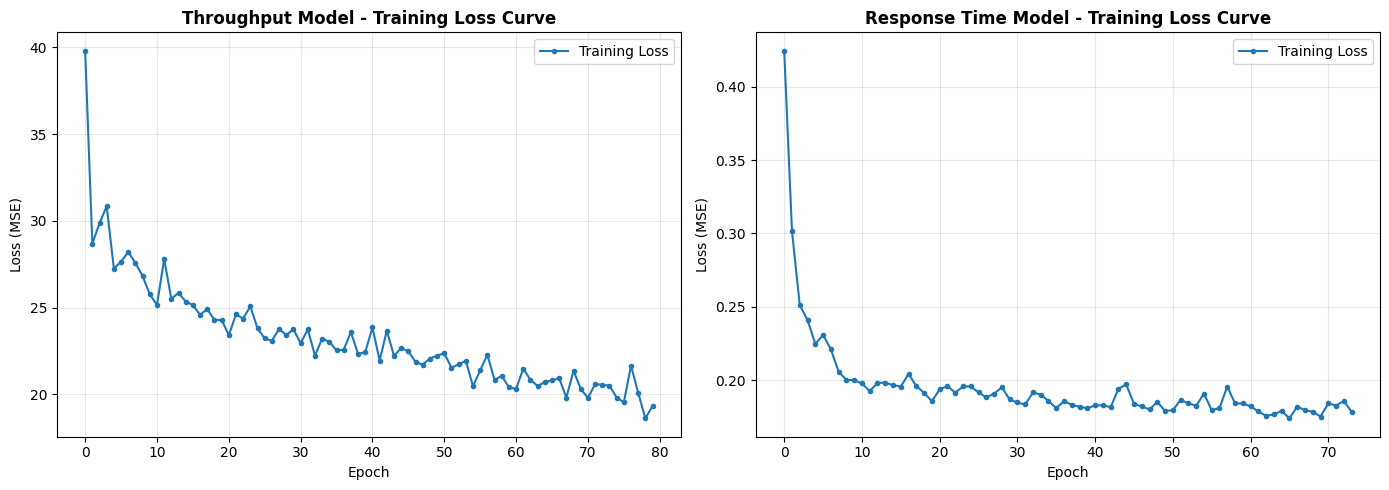

Training loss visualization complete.


In [10]:
# Visualization: Training Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Throughput training loss
axes[0].plot(model_throughput.loss_curve_, label='Training Loss', marker='o', markersize=3)
axes[0].set_title('Throughput Model - Training Loss Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Response Time training loss
axes[1].plot(model_responsetime.loss_curve_, label='Training Loss', marker='o', markersize=3)
axes[1].set_title('Response Time Model - Training Loss Curve', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Training loss visualization complete.")

In [11]:
# ============================================
# SUMMARY AND COMPARISON
# ============================================

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY - TEST DATA PERFORMANCE (v2)")
print("="*80)

summary_df = pd.DataFrame({
    'Metric': ['MAPE', 'SMAPE (90% Robust)', 'RMSE', 'MAE', 'R² Score', 
               'Accuracy ≤90%', 'Accuracy ≤50%', 'Accuracy ≤20%', 'Accuracy ≤10%'],
    'Throughput Model': [
        f"{mape_throughput:.4f}", 
        f"{smape_throughput:.4f}",
        f"{rmse_throughput:.4f}", 
        f"{mae_throughput:.4f}", 
        f"{r2_throughput:.4f}",
        f"{accuracy_90:.2f}%",
        f"{accuracy_50:.2f}%",
        f"{accuracy_20:.2f}%",
        f"{accuracy_10:.2f}%"
    ],
    'ResponseTime Model': [
        f"{mape_responsetime:.4f}", 
        f"{smape_responsetime:.4f}",
        f"{rmse_responsetime:.4f}", 
        f"{mae_responsetime:.4f}", 
        f"{r2_responsetime:.4f}",
        f"{accuracy_90_rt:.2f}%",
        f"{accuracy_50_rt:.2f}%",
        f"{accuracy_20_rt:.2f}%",
        f"{accuracy_10_rt:.2f}%"
    ]
})

print("\n" + summary_df.to_string(index=False))
print("\n" + "="*80)
print("\nNote: SMAPE (Symmetric Mean Absolute Percentage Error) is more robust than MAPE")
print("      and handles edge cases better, especially with near-zero values.")
print("      Accuracy metrics show % of predictions within specified error thresholds.")


MODEL COMPARISON SUMMARY - TEST DATA PERFORMANCE (v2)

            Metric Throughput Model ResponseTime Model
              MAPE           0.4079             1.2091
SMAPE (90% Robust)           0.3146             1.0122
              RMSE           5.2930         32616.7408
               MAE           4.1635         24604.5966
          R² Score          -1.5221            -0.4011
     Accuracy ≤90%           80.00%             93.33%
     Accuracy ≤50%           73.33%             20.00%
     Accuracy ≤20%           43.33%             10.00%
     Accuracy ≤10%           16.67%              6.67%


Note: SMAPE (Symmetric Mean Absolute Percentage Error) is more robust than MAPE
      and handles edge cases better, especially with near-zero values.
      Accuracy metrics show % of predictions within specified error thresholds.
